# Load packages and data

In [12]:
%matplotlib inline

In [13]:
!pip install ISLP

Defaulting to user installation because normal site-packages is not writeable


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ISLP import load_data
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [15]:
# Load Auto data
Auto = load_data("Auto")

# Drop missing values (horsepower contains NaNs)
Auto = Auto.dropna()

# Scatterplot with linear regression

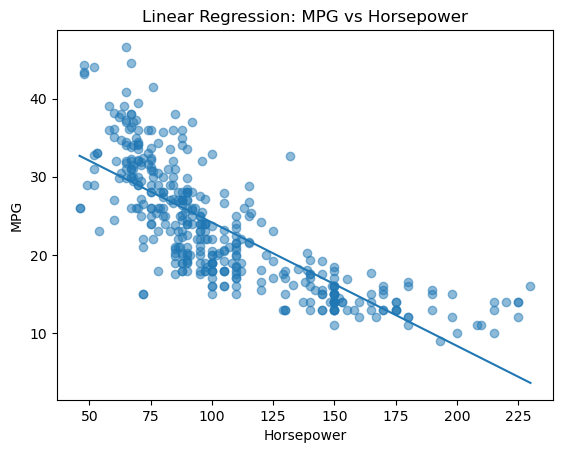

In [16]:
X = Auto[['horsepower']]
y = Auto['mpg']

lin_model = LinearRegression()
lin_model.fit(X, y)

hp_grid = pd.DataFrame(
    np.linspace(Auto['horsepower'].min(), Auto['horsepower'].max(), 200),
    columns=['horsepower']
)

y_lin = lin_model.predict(hp_grid)

plt.scatter(X, y, alpha=0.5)
plt.plot(hp_grid, y_lin)
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Linear Regression: MPG vs Horsepower")
plt.show()

# Polynomial regression (degree 2 and 3)

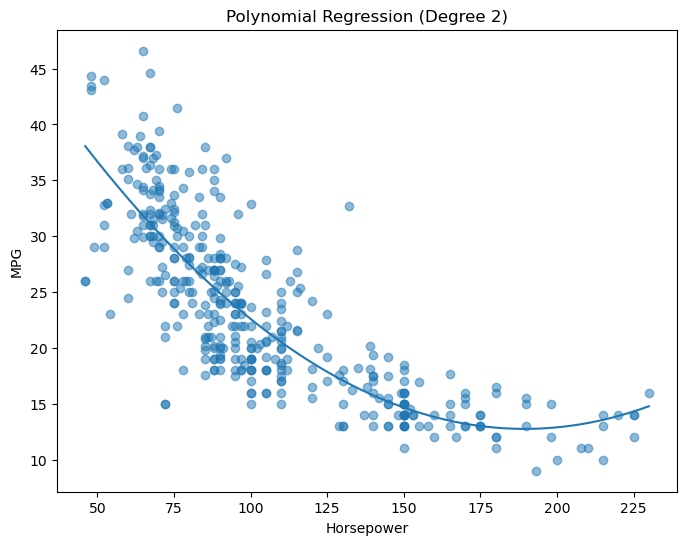

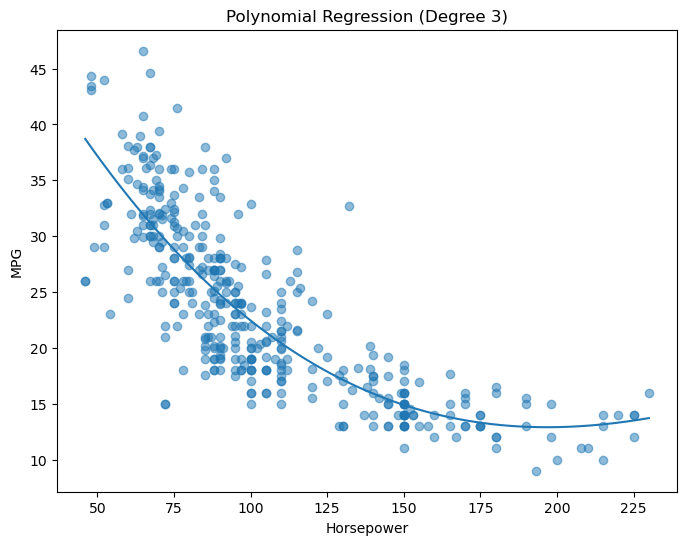

In [17]:
for d in [2, 3]:
    poly_model = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('lin', LinearRegression())
    ])
    
    poly_model.fit(X, y)
    y_poly = poly_model.predict(hp_grid)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(Auto['horsepower'], y, alpha=0.5)
    plt.plot(hp_grid['horsepower'], y_poly)
    plt.xlabel("Horsepower")
    plt.ylabel("MPG")
    plt.title(f"Polynomial Regression (Degree {d})")
    plt.show()

# Regression splines

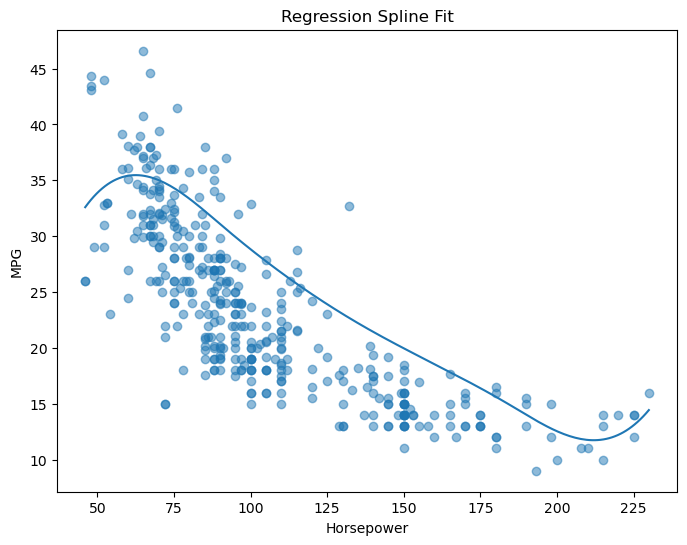

In [19]:
from patsy import dmatrix
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Create spline basis for training data
spline_X = dmatrix(
    "bs(horsepower, df=6, include_intercept=False)",
    {"horsepower": Auto["horsepower"]},
    return_type='dataframe'
)

spline_model = LinearRegression()
spline_model.fit(spline_X, y)

# Create spline basis for prediction grid
spline_grid = dmatrix(
    "bs(horsepower, df=6, include_intercept=False)",
    {"horsepower": hp_grid['horsepower']},
    return_type='dataframe'
)

y_spline = spline_model.predict(spline_grid)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(Auto['horsepower'], y, alpha=0.5)
plt.plot(hp_grid['horsepower'], y_spline)
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Regression Spline Fit")
plt.show()

# Local regression (LOESS)

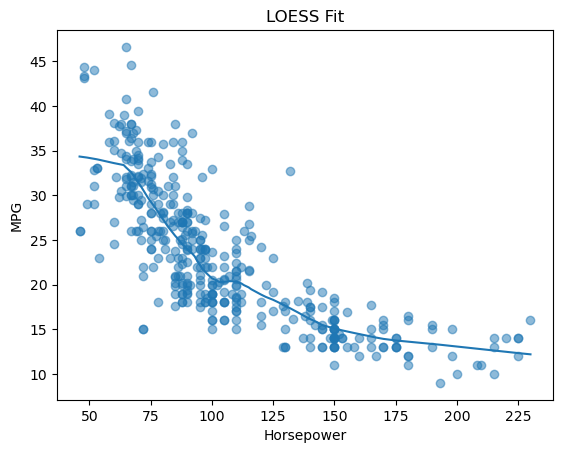

In [20]:
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt

loess_fit = lowess(y, Auto['horsepower'], frac=0.3)

plt.scatter(Auto['horsepower'], y, alpha=0.5)
plt.plot(loess_fit[:, 0], loess_fit[:, 1])
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("LOESS Fit")
plt.show()